In [1]:
# TECHNOLOGY USED: Python (Pandas Library)
import pandas as pd

# Load the data
# 1. Changed 'credit_risk.csv' to 'credit_risk_dataset.csv'
# 2. Used the Absolute Path (r'D:\...') to ensure it works every time
df = pd.read_csv(r'D:\Credit_Risk_Analytics_Project\Raw_Data\credit_risk_dataset.csv')

print(df.head()) # See the first 5 rows


   person_age  person_income person_home_ownership  person_emp_length  \
0          22          59000                  RENT              123.0   
1          21           9600                   OWN                5.0   
2          25           9600              MORTGAGE                1.0   
3          23          65500                  RENT                4.0   
4          24          54400                  RENT                8.0   

  loan_intent loan_grade  loan_amnt  loan_int_rate  loan_status  \
0    PERSONAL          D      35000          16.02            1   
1   EDUCATION          B       1000          11.14            0   
2     MEDICAL          C       5500          12.87            1   
3     MEDICAL          C      35000          15.23            1   
4     MEDICAL          C      35000          14.27            1   

   loan_percent_income cb_person_default_on_file  cb_person_cred_hist_length  
0                 0.59                         Y                           3  


In [2]:
# SKILL: Descriptive Statistics
# TECHNOLOGY: Pandas .describe()
# PURPOSE: Identify outliers (impossible values) and data spread.

stats = df.describe()
print(stats)

         person_age  person_income  person_emp_length     loan_amnt  \
count  32581.000000   3.258100e+04       31686.000000  32581.000000   
mean      27.734600   6.607485e+04           4.789686   9589.371106   
std        6.348078   6.198312e+04           4.142630   6322.086646   
min       20.000000   4.000000e+03           0.000000    500.000000   
25%       23.000000   3.850000e+04           2.000000   5000.000000   
50%       26.000000   5.500000e+04           4.000000   8000.000000   
75%       30.000000   7.920000e+04           7.000000  12200.000000   
max      144.000000   6.000000e+06         123.000000  35000.000000   

       loan_int_rate   loan_status  loan_percent_income  \
count   29465.000000  32581.000000         32581.000000   
mean       11.011695      0.218164             0.170203   
std         3.240459      0.413006             0.106782   
min         5.420000      0.000000             0.000000   
25%         7.900000      0.000000             0.090000   
50%   

In [3]:
# SKILL: Data Integrity Check
# TECHNOLOGY: .isnull().sum()
# PURPOSE: Finding where information is missing.

missing_data = df.isnull().sum()
print("Missing values per column:\n", missing_data)

Missing values per column:
 person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [4]:
# SKILL: Data Cleaning & Outlier Removal
# 1. Remove unrealistic ages (anything over 100)
df = df[df['person_age'] < 100]

# 2. Remove unrealistic employment length (can't work more than your age)
df = df[df['person_emp_length'] < 60]

# 3. Handle Missing Interest Rates (Imputation)
# Instead of deleting, we fill missing rates with the MEDIAN
median_rate = df['loan_int_rate'].median()
df['loan_int_rate'] = df['loan_int_rate'].fillna(median_rate)

print("Data Cleaned! New Shape:", df.shape)

Data Cleaned! New Shape: (31679, 12)


In [5]:
# SKILL: Exploratory Data Analysis (EDA)
# TECHNOLOGY: Correlation Matrix
# PURPOSE: To see which factors (Income, Amount, Interest) lead to Default (loan_status).

# We only correlate numeric columns
correlation = df.select_dtypes(include=['number']).corr()
print(correlation['loan_status'].sort_values(ascending=False))

loan_status                   1.000000
loan_percent_income           0.379823
loan_int_rate                 0.323247
loan_amnt                     0.112188
cb_person_cred_hist_length   -0.016830
person_age                   -0.022130
person_emp_length            -0.085966
person_income                -0.164128
Name: loan_status, dtype: float64


In [6]:
# SKILL: Statistical Imputation
# TECHNOLOGY: .fillna() and .median()

# We use the Median because it is not affected by outliers
median_interest = df['loan_int_rate'].median()

# Fill the missing values
df['loan_int_rate'] = df['loan_int_rate'].fillna(median_interest)

# Confirm there are zero missing values now
print("Missing values in Interest Rate:", df['loan_int_rate'].isnull().sum())

Missing values in Interest Rate: 0


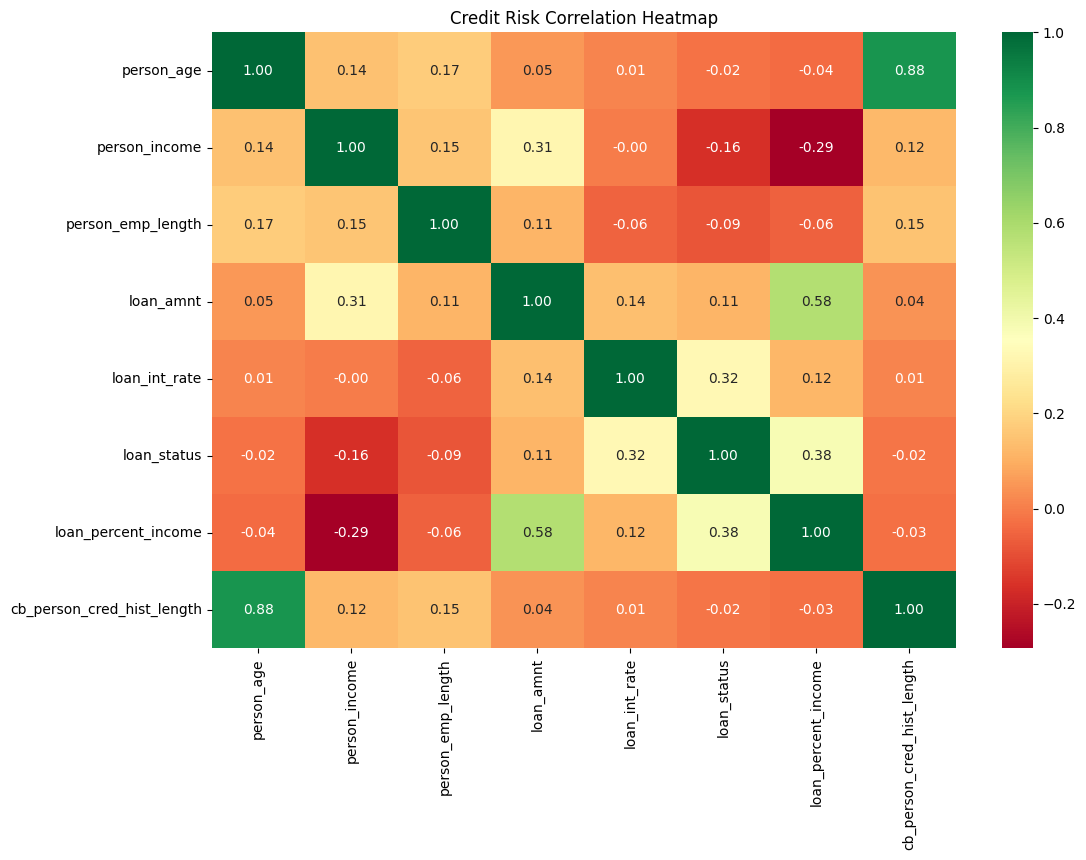

In [8]:
# Create numeric_df by selecting only the columns with numbers
numeric_df = df.select_dtypes(include=['number'])

# Now your heatmap code will work
plt.figure(figsize=(12, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f')
plt.title('Credit Risk Correlation Heatmap')
plt.show()


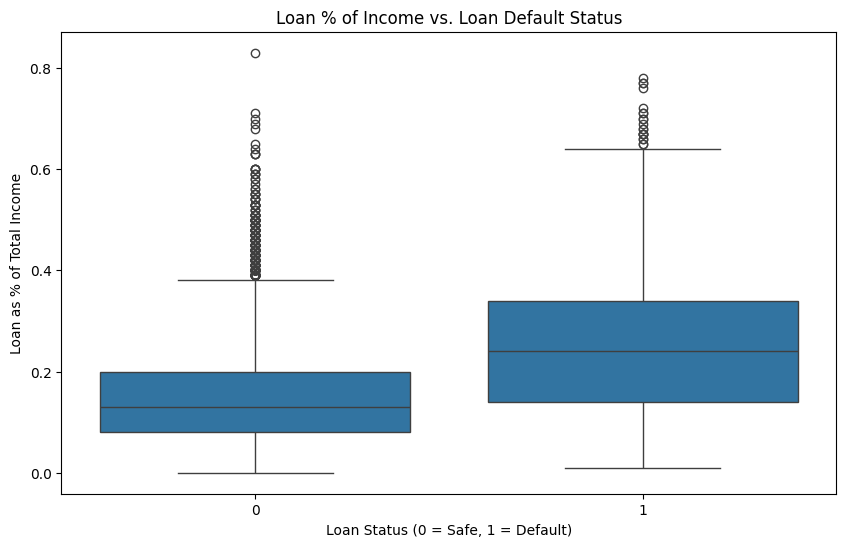

In [9]:
# SKILL: Categorical Analysis
# PURPOSE: Visualizing the 'Hook' (Loan % of Income vs Default)

plt.figure(figsize=(10, 6))
sns.boxplot(x='loan_status', y='loan_percent_income', data=df)
plt.title('Loan % of Income vs. Loan Default Status')
plt.xlabel('Loan Status (0 = Safe, 1 = Default)')
plt.ylabel('Loan as % of Total Income')
plt.show()